# Projektdokumentation: Schlafprognose

**Angewandtes Machine Learning**  
**Wintersemester 2025**  
**Henry Marx**
**131242027**

---


## 1. Problembeschreibung

### 1.1 Definition des Problems

Das Ziel dieses Projekts ist die Vorhersage der Schlafqualität basierend auf Faktoren wie Technologienutzung, Stress-Level, sportliche Aktivität, Bildschirmzeit und vielen weiteren Faktoren. Das Problem gilt als gelöst, wenn das Modell eine reproduzierbare Prognose für die Schlafqualität treffen kann, die auf den zur Verfügung stehenden Trainingsdaten beruht. Dabei ist wichtig zu beachten, dass die Schlafqualität im Datensatz mit diskreten Werten zwischen eins und fünf abgebildet ist, wobei eins für sehr schlechte und fünf für sehr gute Schlafqualität steht. Da die Zielvariable diskrete Werte annimmt, wird ein Klassifikationsansatz gewählt, der die Schlafqualität in fünf separate Klassen kategorisiert. Als Vergleich wird zusätzlich ein Deep Learning-Ansatz mit der Keras API implementiert, um die Leistungsfähigkeit verschiedener Modellarchitekturen zu evaluieren. 

### 1.2 Relevanz und Anwendungskontext

Schlechte Schlafqualität ist ein weit verbreitetes Problem in der modernen Gesellschaft. Die zunehmende Nutzung digitaler Geräte, insbesondere vor dem Schlafengehen, wird häufig mit Schlafstörungen in Verbindung gebracht. Dieses Projekt untersucht den komplexen Zusammenhang zwischen verschiedenen Lebensstilfaktoren und der Schlafqualität. Dabei werden insbesondere die Nutzungsgewohnheiten verschiedener digitaler Geräte wie Smartphone, Laptop, Tablet, Desktop und Smartwatch analysiert. Zusätzlich werden Stress-Faktoren und Wellness-Indikatoren wie körperliche Aktivität, Achtsamkeitsübungen und Ernährungsgewohnheiten in die Betrachtung einbezogen. Um ein möglichst vollständiges Bild zu erhalten, werden auch demografische Merkmale wie Alter, Geschlecht und Wohnort berücksichtigt, die möglicherweise Einfluss auf die Schlafqualität haben könnten.

### 1.3 Zielsetzung

Das entwickelte System soll präzise Vorhersagen der Schlafqualität ermöglichen und dabei identifizieren, welche Faktoren den größten Einfluss auf die Schlafqualität haben. Durch den systematischen Vergleich verschiedener Machine Learning-Ansätze, insbesondere XGBoost in einer Baseline- und einer optimierten Variante sowie eines Keras Neural Networks, werden die jeweiligen Stärken und Schwächen der Methoden analysiert. Das Projekt verfolgt dabei mehrere zentrale Ziele. Zum einen sollen robuste Klassifikationsmodelle für die Vorhersage der fünf Schlafqualitäts-Klassen entwickelt werden, zum anderen soll eine umfassende Feature-Analyse durchgeführt werden, um die wichtigsten Einflussfaktoren zu identifizieren. Darüber hinaus wird ein detaillierter Methodenvergleich zwischen Gradient Boosting und Deep Learning angestrebt, wobei besonderer Wert auf die Generalisierungsfähigkeit der Modelle auf ungesehenen Test-Daten gelegt wird.

### 1.4 Erwartete Herausforderungen

Die größte Herausforderung stellt das extreme Class Imbalance dar, bei dem Klasse vier mit 58% den Datensatz dominiert, während Klasse eins nur mit einem einzigen Sample von insgesamt 5000 Beobachtungen vertreten ist. Dies führt dazu, dass das Modell tendenziell die dominanten Klassen bevorzugt. Zudem erschweren nicht-lineare Zusammenhänge und Schwellenwert-Effekte die Vorhersage, da beispielsweise die Schlafqualität bei mehr als acht Stunden täglicher Bildschirmzeit drastisch abfällt, während bei unter vier Stunden kaum ein Effekt messbar ist. Die Multikollinearität zwischen den Features, insbesondere zwischen der gesamten Bildschirmzeit und den einzelnen Gerätenutzungen, kann die Modellinterpretation erschweren und zu instabilen Koeffizienten führen.

## 2. Datenquelle und Datenbeschreibung

### 2.1 Herkunft der Daten

Die Datengrundlage für dieses Projekt bildet der Datensatz "Tech Use, Stress, and Wellness Survey", der im lokalen Repository unter dem Pfad `data/raw/Tech_Use_Stress_Wellness.csv` verfügbar ist. Der Datensatz wurde für akademische Zwecke von der Plattform Kaggle bezogen und enthält Umfragedaten zum Zusammenhang zwischen Technologienutzung, Stresslevel und Wellness-Indikatoren. Hier ist der Link: https://www.kaggle.com/datasets/nagpalprabhavalkar/tech-use-and-stress-wellness

### 2.2 Datenumfang

Der Datensatz umfasst insgesamt 5000 Beobachtungen, die als Grundlage für das Training und die Evaluation der Modelle dienen. Der Rohdatensatz enthält 25 Features sowie die Zielvariable sleep_quality, die verschiedene Aspekte der Technologienutzung wie Bildschirmzeit verschiedener Geräte und Social-Media-Nutzung, demografische Merkmale wie Alter, Geschlecht und Wohnort sowie Wellness-Faktoren wie Stress-Level, körperliche Aktivität und Ernährungsgewohnheiten abbilden. Im Rahmen der Datenvorverarbeitung wurden Variablen teilweise transformiert. Gleichzeitig wurden fünf Features aus dem Datensatz entfernt, da sie entweder nicht relevant für die Vorhersage waren oder redundante Informationen enthielten: user_id als reine Identifikationsvariable, sleep_duration_hours aufgrund der starken Korrelation mit der Zielvariable, weekly_anxiety_score und weekly_depression_score wegen fehlender Werte sowie caffeine_intake_mg_per_day, das zu caffeine_mg umbenannt wurde. Durch diese Transformationen ergibt sich für den prozessierten Datensatz eine finale Feature-Anzahl von 22 zuzüglich der Zielvariable, die dem Modell eine ausgewogene Informationsbasis bietet. Die Zielvariable sleep_quality ist eine diskrete ordinale Variable mit ganzzahligen Werten im Bereich von eins bis fünf, wobei eins für sehr schlechte und fünf für sehr gute Schlafqualität steht.

### 2.3 Feature-Beschreibung

Die folgende Tabelle zeigt alle Features des prozessierten Datensatzes mit ihren Datentypen und Beschreibungen:

| Variable | Datentyp | Beschreibung |
|----------|----------|--------------|
| **age** | numerisch | Alter der Person |
| **daily_screen_time_hours** | numerisch | Gesamte tägliche Bildschirmzeit (Stunden) |
| **phone_usage_hours** | numerisch | Smartphone-Nutzung (Stunden/Tag) |
| **laptop_usage_hours** | numerisch | Laptop-Nutzung (Stunden/Tag) |
| **tablet_usage_hours** | numerisch | Tablet-Nutzung (Stunden/Tag) |
| **tv_usage_hours** | numerisch | Fernseh-Nutzung (Stunden/Tag) |
| **social_media_hours** | numerisch | Social-Media-Nutzung (Stunden/Tag) |
| **work_related_hours** | numerisch | Arbeitsbezogene Bildschirmzeit (Stunden/Tag) |
| **entertainment_hours** | numerisch | Unterhaltungsbezogene Bildschirmzeit (Stunden/Tag) |
| **gaming_hours** | numerisch | Gaming-Zeit (Stunden/Tag) |
| **physical_activity_hours_per_week** | numerisch | Körperliche Aktivität (Stunden/Woche) |
| **caffeine_mg** | numerisch | Koffeinkonsum (mg/Tag) |
| **mindfulness_minutes_per_day** | numerisch | Achtsamkeitsübungen (Minuten/Tag) |
| **mental_health_score** | numerisch | Mental-Health-Score (0-100) |
| **mood_rating** | numerisch | Stimmungsbewertung |
| **stress_level** | numerisch | Subjektiver Stress-Level |
| **uses_wellness_apps** | binär | Nutzung von Wellness-Apps (0=Nein, 1=Ja) |
| **eats_healthy** | binär | Gesunde Ernährung (0=Nein, 1=Ja) |
| **gender_Male** | binär | Geschlecht männlich (0=Nein, 1=Ja) |
| **gender_Other** | binär | Geschlecht divers (0=Nein, 1=Ja) |
| **location_type_Suburban** | binär | Wohnort Vorstadt (0=Nein, 1=Ja) |
| **location_type_Urban** | binär | Wohnort Stadt (0=Nein, 1=Ja) |
| **sleep_quality** | **Zielvariable** | Schlafqualität (1-5, diskrete Werte) |

**Hinweise:**
- Geschlecht: Baseline ist Female (beide gender-Features = 0)
- Wohnort: Baseline ist Rural (beide location_type-Features = 0)
- Alle numerischen Features wurden im Original-Datensatz erfasst und in den prozessierten Datensatz übernommen

## 3. Explorative Datenanalyse (EDA)

Die EDA dient dazu, die Datenstruktur zu verstehen, Muster zu erkennen und potenzielle Probleme (Outliers, Missing Values, Class Imbalance) zu identifizieren. Für dieses Kapitel exististiert ein eigenes Skript unter dem Porjektordner scripts/eda.py. Dieses Skript kann ausgeführt werden und generiert verschiedene Diagramme unter dem Projektordner EDA.  

### 3.2 Korrelationsanalyse

Die Korrelationsanalyse untersucht lineare Zusammenhänge zwischen den Features und der Zielvariable sleep_quality. Dabei wird der Korrelationskoeffizient berechnet, der Werte zwischen -1 (perfekte negative Korrelation) und +1 (perfekte positive Korrelation) annehmen kann. Ein Wert nahe 0 deutet auf keinen linearen Zusammenhang hin. Ziel der Analyse ist die Identifikation der einflussreichsten Features für die Schlafqualität sowie die Erkennung von Multikollinearität zwischen Features, beispielsweise wenn daily_screen_time_hours stark mit einzelnen Geräte-Nutzungen korreliert. Es wird erwartet, dass Features wie physical_activity, mindfulness_minutes und mental_health_score positiv mit der Schlafqualität korrelieren, während hohe Bildschirmzeit, Stress-Level und Koffeinkonsum eine negative Korrelation aufweisen sollten. Die Visualisierung erfolgt zweifach: Ein horizontales Balkendiagramm zeigt die Korrelationen aller Features mit der Zielvariable sortiert, während die Heatmap die Korrelationen zwischen allen Features darstellt und dabei potenzielle Multikollinearitäten aufdeckt.

### 3.3 Muster, Trends und Auffälligkeiten

**Korrelationsanalyse:** Die Zielvariable sleep_quality zeigt die stärksten positiven Korrelationen mit mental_health_score (r=0.43), mood_rating (r=0.38) und gaming_hours (r=0.31). Negative Korrelationen bestehen primär mit daily_screen_time_hours (r=-0.55), stress_level (r=-0.40), social_media_hours (r=-0.38) und work_related_hours (r=-0.35). Die Bildschirmzeit weist die stärkste negative Beziehung auf.

**Schwellenwerte und nicht-lineare Beziehungen:** Bei der Bildschirmzeit zeigt sich ein klarer Schwellenwert-Effekt: Personen mit <4h täglicher Bildschirmzeit haben durchschnittlich eine Schlafqualität von 4.42, bei 4-8h sinkt diese auf 3.88 und bei 8-12h auf 3.24. Ein ähnliches Muster zeigt sich bei Social Media (<2h: 4.42, 2-4h: 4.07, 4-6h: 3.75) und Phone Usage (<2h: 4.14, 2-4h: 3.86, 4-6h: 3.65). Der Stress-Level zeigt einen nahezu linearen negativen Trend: Von Stress-Level 1 (Schlafqualität 4.48) bis Level 10 (3.63) sinkt die Schlafqualität kontinuierlich um etwa 0.85 Punkte.

**Demografische Unterschiede:** Geschlecht und Wohnort zeigen keine signifikanten Unterschiede in der Schlafqualität (alle Gruppen zwischen 4.00-4.02). Diese Variablen haben keinen nennenswerten Einfluss auf die Zielvariable und könnten für die Modellierung weniger relevant sein.

### 3.4 Class Imbalance Problem

Eine zentrale Herausforderung des Datensatzes zeigt sich in der extremen Ungleichverteilung der Zielvariable sleep_quality. Die 5000 Beobachtungen verteilen sich höchst ungleichmäßig über die fünf Schlafqualitäts-Klassen. Klasse eins ist mit nur einem einzigen Sample vertreten, was 0,02% des Datensatzes entspricht. Klasse zwei umfasst 31 Samples bei 0,6%. Klasse drei enthält 979 Samples entsprechend 19,6%. Mit 2898 Samples dominiert Klasse vier den Datensatz bei 58%. Klasse fünf schließlich beinhaltet 1091 Samples bei 21,8%.

Das resultierende Imbalance Ratio von 2898:1 zwischen größter und kleinster Klasse ist extrem und stellt eine erhebliche Herausforderung für die Modellierung dar. Machine Learning Algorithmen tendieren dazu, die Mehrheitsklasse zu bevorzugen, da sie durch häufigere Repräsentation im Training stärker gelernt wird. Ein naives Modell, das stets Klasse vier vorhersagt, würde bereits eine Accuracy von 58% erreichen, ohne tatsächlich Muster in den Features zu erkennen. Die Klassen eins und zwei sind mit insgesamt nur 32 Samples praktisch nicht lernbar, da moderne Machine Learning Algorithmen typischerweise mindestens einige Dutzend Beispiele pro Klasse benötigen, um robuste Muster zu identifizieren.

Die Konsequenzen dieses Imbalance zeigen sich auf mehreren Ebenen. Erstens ist kein stratifizierter Train-Test-Split möglich, da Klasse eins nur ein einziges Sample enthält und stratification mindestens zwei Samples pro Klasse erfordert. Dies führt dazu, dass Klasse eins entweder vollständig im Training-Set oder vollständig im Test-Set landet, aber niemals in beiden. Zweitens werden die Standard-Metriken wie Accuracy verzerrt, da ein Modell hohe Accuracy erreichen kann, indem es einfach immer die häufigste Klasse vorhersagt. Drittens besteht die Gefahr, dass das Modell die seltenen Klassen ignoriert und sich ausschließlich auf die Unterscheidung zwischen den häufigen Klassen drei, vier und fünf konzentriert.

## 4. Datenvorverarbeitung

Die Datenvorverarbeitung ist entscheidend für die Modellperformance und wurde in mehreren aufeinander aufbauenden Schritten durchgeführt, um die Rohdaten in eine für Machine Learning geeignete Form zu bringen.

### 4.0 Outlier-Behandlung

Die Behandlung von Ausreißern erfolgt in diesem Projekt differenziert nach Modell-Typ. Für XGBoost werden Outliers bewusst nicht entfernt, da tree-based Modelle mit Schwellenwerten statt absoluten Werten arbeiten. Ein Extremwert von beispielsweise 20 Stunden Bildschirmzeit wird einfach als größer als ein bestimmter Schwellenwert kategorisiert, wobei die genaue Höhe des Wertes irrelevant ist. Tree-based Modelle sind von Natur aus robust gegenüber Outliers, und eine Entfernung könnte valide Extremfälle wie echte Power-User eliminieren und damit zu Informationsverlust führen.
Für das Keras Neural Network hingegen wird IQR-basiertes Outlier-Capping angewendet, da neuronale Netze auf Gradienten basieren und sensitiv auf extreme Werte reagieren. Dabei werden für kontinuierliche Features das 1. und 3. Quartil berechnet sowie der Interquartilsabstand IQR ermittelt. Werte unterhalb von Q1 - 1,5 * IQR oder oberhalb von Q3 + 1,5 * IQR werden auf diese Grenzen beschränkt. Binäre Features wie gender und location_type bleiben dabei unangetastet, da sie nur die Werte null und eins annehmen können.

### 4.1 Behandlung fehlender Werte

Die Behandlung fehlender Werte erfolgt strategisch nach Feature-Typ. Für numerische Features wie Alter wird die Median-Imputation verwendet, da der Median im Gegensatz zum Mittelwert robust gegenüber Outliers ist. Bei optionalen Nutzungsfeatures wie physical_activity_hours_per_week, mindfulness_minutes_per_day und caffeine_intake erfolgt eine Null-Imputation, da fehlende Werte semantisch Nicht-Nutzung bedeuten. Dieser Ansatz hat den entscheidenden Vorteil, dass alle 5000 Samples erhalten bleiben und keine Datenzeilen gelöscht werden müssen, was die maximale Datenausnutzung sicherstellt.

### 4.2 Feature Engineering

Im Rahmen des Feature Engineering wurden mehrere Transformationen implementiert. Es wurden nutzungsartspezifische Features wie social_media_hours, work_related_hours, entertainment_hours und gaming_hours extrahiert. Diese Separation ist wichtig, da verschiedene Geräte und Nutzungsarten unterschiedliche Auswirkungen auf die Schlafqualität haben können. Gaming vor dem Schlafengehen könnte beispielsweise anders wirken als Fernsehen.
Für konsistente Benennung wurde caffeine_intake_mg_per_day zu caffeine_mg umbenannt. Binäre Features wie uses_wellness_apps und eats_healthy wurden von True/False in numerische Werte eins und null konvertiert, wobei auch das Text-Format mit "True" und "False" Strings korrekt behandelt wurde. Dies ermöglicht die numerische Repräsentation für den Modell-Input.
Nach diesen Transformationen ergibt sich eine finale Feature-Anzahl von 22, bestehend aus 18 numerischen Features wie age, screen time, activity und health scores sowie vier One-Hot-kodierten Features für gender_Male, gender_Other, location_type_Suburban und location_type_Urban. Bewusst entfernt wurden user_id als eindeutiger Identifier ohne prädiktive Relevanz, sleep_duration_hours wegen zu starker Korrelation mit der Zielvariable, sowie weekly_anxiety_score und weekly_depression_score aufgrund der Redundanz mit mental_health_score.

### 4.3 Encoding kategorialer Variablen

Für die Kodierung kategorialer Variablen wird One-Hot Encoding verwendet. Das Feature gender mit den Kategorien Female, Male und Other wird in die binären Features gender_Male und gender_Other kodiert, wobei Female als Baseline dient und durch beide Features gleich null repräsentiert wird. Analog wird location_type mit den Kategorien Rural, Suburban und Urban in location_type_Suburban und location_type_Urban kodiert, wobei Rural die Baseline darstellt.

### 4.4 Feature-Skalierung

Die Notwendigkeit der Feature-Skalierung ergibt sich aus den unterschiedlichen Größenordnungen der Features. Während age einen Wertebereich von etwa 18 bis 70 mit einem Bereich von circa 50 hat, erstreckt sich caffeine_mg von null bis 800 mit einem Bereich von 800, und mood_rating liegt zwischen eins und zehn mit einem Bereich von neun. Ohne Skalierung würden Features mit großen Werten bei vielen Algorithmen dominieren, obwohl alle Features gleich wichtig sein könnten.
In diesem Projekt wird Standardisierung mittels StandardScaler verwendet, die den Mittelwert abzieht und durch die Standardabweichung teilt, sodass das Ergebnis einen Mittelwert von null und eine Standardabweichung von eins hat. Im Gegensatz zur Min-Max-Normalisierung, die auf einen festen Bereich von null bis eins skaliert, hat die Standardisierung einen unbegrenzten Wertebereich typischerweise zwischen minus drei und plus drei und erhält dabei die Outlier-Information.
Die Implementierung erfolgt modellspezifisch. Für Keras Neural Networks ist StandardScaler zwingend notwendig, da Gradient Descent basierend auf Distanzen optimiert und Features mit Wertebereichen von null bis tausend Features mit Bereichen von null bis eins dominieren würden. Die Skalierung sorgt für symmetrische Optimierung, schnellere Konvergenz und numerische Stabilität. Für XGBoost hingegen ist keine Skalierung notwendig, da tree-based Modelle mit Schwellenwerten arbeiten. Ein Split wie "Bildschirmzeit kleiner gleich sechs Stunden vs. größer sechs Stunden" bleibt funktional identisch, unabhängig davon ob die Daten im Original-Bereich von null bis 24 Stunden oder skaliert von null bis eins vorliegen.
Als Best Practice wird fit_transform nur auf Trainingsdaten angewendet, um Mittelwert und Standardabweichung zu lernen, während transform auf Testdaten die gleichen Parameter verwendet und damit Data Leakage verhindert. Der trainierte Scaler wird mittels joblib.dump gespeichert für spätere Predictions.

### 4.6 Class Imbalance Problem

Die Auswirkungen des Ungleichgewichts sind erheblich, da Modelle zur Mehrheitsklasse vier tendieren und die Klassen eins und zwei praktisch unmöglich zu lernen sind aufgrund zu weniger Samples. Eine naive Baseline, die immer Klasse vier vorhersagt, würde bereits 58% Accuracy erreichen.
Als Hauptlösung werden Class Weights implementiert. Für XGBoost wird der sample_weight Parameter beim Training verwendet, wobei die Gewichte mittels sklearn.utils.class_weight.compute_sample_weight mit dem Parameter balanced berechnet werden. Für Keras wird ein class_weight Dictionary beim fit übergeben, berechnet durch sklearn.utils.class_weight.compute_class_weight ebenfalls mit balanced. Diese Gewichtung führt dazu, dass seltene Klassen eine höhere Gewichtung beim Training erhalten und die Loss-Funktion automatisch für jede Klasse angepasst wird.
Zusätzlich wurden die Evaluation-Metriken angepasst, indem der Weighted F1-Score verwendet wird, der die Klassenverteilung berücksichtigt und die Confusion Matrix zur detaillierten Fehleranalyse.
Trotz der implementierten Class Weights bleibt das extreme Imbalance herausfordernd, und es wird erwartet, dass die Klassen eins und zwei voraussichtlich schlecht vorhergesagt werden, während die Klassen drei bis fünf bessere Performance zeigen.

## 6. Modellauswahl und Modellarchitektur

### 6.1 Begründung der Modellauswahl

Für dieses Projekt wurden zwei unterschiedliche Modell-Architekturen implementiert, um einen umfassenden Vergleich zu ermöglichen. Die Kombination aus XGBoost und Keras Neural Networks erlaubt eine detaillierte Analyse der jeweiligen Stärken und Schwächen bei der Klassifikation ordinaler Zielvariablen mit extremer Class Imbalance.

#### XGBoost als Baseline

XGBoost (Extreme Gradient Boosting) gilt als einer der leistungsfähigsten Algorithmen für tabellarische Daten und dominiert in Kaggle-Wettbewerben bei strukturierten Datasets. Die Entscheidung für XGBoost basiert auf mehreren zentralen Vorteilen. Tree-based Modelle arbeiten mit Schwellenwerten statt absoluten Werten, wodurch sie von Natur aus robust gegenüber Outliers sind. Extremwerte von beispielsweise 20 Stunden pro Tag Bildschirmzeit werden automatisch korrekt kategorisiert, ohne das Modell zu destabilisieren. Ein weiterer entscheidender Vorteil liegt darin, dass keine Feature-Normalisierung notwendig ist, was Preprocessing-Aufwand spart und potenzielle Fehlerquellen eliminiert.
XGBoost bietet zudem integrierte Gain- und Split-basierte Metriken zur direkten Analyse der Feature Importance, was die Interpretierbarkeit erheblich verbessert. Mit 5000 Samples bewegt sich der Datensatz in einem eher kleinen Bereich, der für XGBoost dennoch gut geeignet ist. Die eingebaute Regularisierung durch Parameter wie max_depth, min_child_weight und gamma verhindert Overfitting automatisch, während das parallelisierte Training durch die tree-basierte Struktur für schnelle Trainingszeiten sorgt.
Bewusst akzeptiert werden dabei die Einschränkungen, dass Feature-Interaktionen explizit in den Bäumen entdeckt werden müssen und das Modell weniger flexibel bei sehr komplexen nicht-linearen Mustern ist als Deep Neural Networks. Aufgrund der hohen Effizienz bei tabellarischen Daten wird erwartet, dass XGBoost eine starke Baseline darstellt.

#### Keras Neural Network als flexibles Vergleichsmodell

Keras mit TensorFlow ermöglicht flexibles Deep Learning und wurde gewählt, um die Leistungsfähigkeit neuronaler Netze bei dieser spezifischen Problemstellung zu evaluieren. Der Hauptvorteil liegt in der Fähigkeit, hochdimensionale Interaktionen zwischen Features zu lernen.
Die flexible Architektur erlaubt freie Wahl von Layer-Anzahl, Neuronen und Aktivierungsfunktionen, während moderne Regularisierungstechniken wie Dropout, Batch Normalization und L2-Regularization robustes Training ermöglichen. Keras kann subtile Muster erkennen, die XGBoost möglicherweise übersieht, und ermöglicht einen direkten Vergleich zwischen Tree-based und Gradient-based Optimierung.
Allerdings erfordert der Einsatz neuronaler Netze zusätzliche Maßnahmen. Feature-Normalisierung mittels StandardScaler ist zwingend notwendig, was einen zusätzlichen Preprocessing-Schritt bedeutet. Das Hyperparameter-Tuning gestaltet sich aufwändiger, da Learning Rate, Batch Size, Layer-Größen und Dropout-Raten manuell optimiert werden müssen. Bei kleineren Datasets wie diesem mit 5000 Samples besteht ein erhöhtes Risiko für Overfitting, weshalb Dropout und Early Stopping essentiell sind. Für tabellarische Daten wird erwartet, dass Keras vergleichbar oder leicht schlechter als XGBoost abschneidet, da Deep Learning primär bei Bildern, Text und Sequenzen seine Stärken ausspielt.

#### Klassifikationsansatz für ordinale Zielvariablen

Für die Modellierung wird ein Klassifikationsansatz gewählt, bei dem sleep_quality als fünf diskrete Klassen behandelt wird. Zur Verarbeitung werden die Werte von eins bis fünf in null bis vier transformiert, um der 0-basierten Indexierung gängiger Machine Learning-Frameworks zu entsprechen.
Der Klassifikationsansatz bietet mehrere Vorteile für diese Problemstellung. Vorhersagen sind stets ganzzahlig und entsprechen der natürlichen Repräsentation der Ground Truth. Durch Softmax-Aktivierung im Output-Layer können Wahrscheinlichkeitsverteilungen über alle fünf Klassen ausgegeben werden, was zusätzliche Interpretationsmöglichkeiten bietet. Ein Modell kann beispielsweise 60% Wahrscheinlichkeit für Klasse 4 und 30% für Klasse 3 vorhersagen, was Unsicherheit in der Vorhersage transparent macht.
Die Herausforderung bei ordinalen Klassifikationsproblemen besteht darin, dass Standard-Klassifikationsmetriken die ordinale Struktur nicht berücksichtigen. Eine Vorhersage von Klasse zwei statt vier wird identisch bewertet wie eine Vorhersage von zwei statt fünf, obwohl erstere näher an der Wahrheit liegt.

#### Zusammenfassung der Modell-Strategie

Durch den Vergleich von drei Modellvarianten wird evaluiert, welcher Ansatz für die Klassifikation ordinaler Zielvariablen mit extremem Class Imbalance am besten geeignet ist. XGBoost Baseline dient als Referenz mit Standardparametern, XGBoost Tuned testet die Verbesserung durch Hyperparameter-Optimierung, und Keras Neural Network evaluiert die Leistungsfähigkeit von Deep Learning bei dieser Problemstellung. XGBoost bietet direkte Feature Importance-Analyse und Robustheit, während Keras die Fähigkeit zur Erfassung komplexer nicht-linearer Interaktionen zwischen Features testet. Das Ziel besteht darin, durch den systematischen Vergleich aller drei Modelle die optimale Architektur für die Vorhersage der Schlafqualität zu identifizieren und dabei fundierte Erkenntnisse über die Trade-offs zwischen verschiedenen Ansätzen zu gewinnen.

### 6.2 Hyperparameter und deren Wahl

Das Ziel besteht darin, durch den systematischen Vergleich beider Modelle die optimale Architektur für die Vorhersage der Schlafqualität zu identifizieren und dabei fundierte Erkenntnisse über die jeweiligen Trade-offs zwischen Tree-based und Neural Network-Ansätzen zu gewinnen.

#### XGBoost Classifier Hyperparameter

| Parameter | Baseline-Wert | Tuning-Range | Begründung |
|-----------|---------------|--------------|------------|
| **n_estimators** | 300 | 200-500 | Mehr Bäume ermöglichen besseres Lernen komplexer Patterns, Baseline erhöht für stärkere Ausgangsbasis |
| **max_depth** | 6 | 4-8 | Tiefere Bäume können komplexere Feature-Interaktionen erfassen, kritisch bei schwachem Signal |
| **learning_rate** | 0.05 | 0.03-0.1 | Konservative Learning Rate für stabile Konvergenz bei Class Imbalance |
| **min_child_weight** | 3 | 1-7 | Wichtig für Class Imbalance: Höhere Werte verhindern Overfitting auf seltene Klassen (nur 1 Sample in Klasse 0!) |
| **subsample** | - | 0.7-0.9 | Anteil der Samples pro Baum, höhere Werte für mehr Stabilität bei kleinem Dataset |
| **colsample_bytree** | - | 0.6-0.9 | Anteil der Features pro Baum, höhere Werte nutzen mehr Information |
| **gamma** | - | 0-0.2 | Minimum Loss Reduction für Split, niedrige Werte erlauben mehr Splits |
| **reg_alpha** | - | 0-0.5 | L1-Regularisierung für Feature Selection |
| **reg_lambda** | - | 1.0-2.0 | L2-Regularisierung zur Gewichtsreduzierung |

**Tuning-Strategie**: RandomizedSearchCV mit 40 Iterationen, PredefinedSplit (80/20) statt K-Fold wegen extremem Class Imbalance. Nach Tuning wird das beste Modell mit Class Weights auf dem vollen Training Set nachtrainiert.

#### Keras Neural Network Hyperparameter

| Parameter | Wert | Begründung |
|-----------|------|------------|
| **learning_rate** | 0.003 | Reduziert von 0.005 für langsamere, stabilere Konvergenz (verhindert frühes Plateau) |
| **batch_size** | 64 | Erhöht von 32 für stabilere Gradienten bei 4000 Training Samples |
| **epochs** | 500 | Maximum mit Early Stopping (patience=20, reduziert von 30) |
| **architecture** | 128→96→64→32→5 | Pyramidale Struktur mit abnehmender Neuronen-Anzahl für Feature-Abstraktion || **dropout_rate** | 0.3 (L1-2), 0.2 (L3-4) | Stärkeres Dropout in frühen Layern verhindert Overfitting bei kleinem Dataset || **L2_regularization** | 0.001 (L1-2), 0.0005 (L3-4) | Gewichtsbestrafung reduziert Overfitting-Risiko || **batch_normalization** | Layer 1-3 | Stabilisiert Training, ermöglicht höhere Learning Rates || **optimizer** | Adam (clipvalue=1.0) | Adaptive Learning Rate mit Gradient Clipping gegen explodierende Gradienten || **early_stopping_patience** | 20 | Reduziert von 30 für schnelleres Abbruchkriterium || **reduce_lr_patience** | 8 | Reduziert Learning Rate bei Plateau (factor=0.5, min_lr=0.0001) || **class_weights** | balanced | Wichtig für extremes Imbalance (Klasse 0: Gewicht ~2500, Klasse 3: Gewicht ~0.86)

Die Architektur balanciert Modellkapazität (128 Neuronen in L1) mit Regularisierung (Dropout, L2, BatchNorm). Frühe Stopping-Mechanismen (EarlyStopping, ReduceLROnPlateau) verhindern Overfitting und verschwendete Rechenzeit. Class Weights kompensieren das extreme Imbalance, können aber die fundamentale Limitierung (nur 1 Sample in Klasse 0) nicht vollständig lösen.

## 7. Training und Modellanalyse

In diesem Kapitel werden drei verschiedene Machine Learning Modelle trainiert und analysiert:

1. **XGBoost Baseline** (7.1) - Standardkonfiguration als Referenz
2. **XGBoost Tuned** (7.2) - Optimiert durch Hyperparameter-Tuning  
3. **Keras Neural Network** (7.3) - Deep Learning Ansatz

Jedes Unterkapitel folgt derselben Struktur. Die Evaluation erfolgt konsistent über alle Modelle hinweg, sodass ein direkter Vergleich möglich ist.

### 7.1 XGBoost Baseline

#### 7.1.1 Modellarchitektur & Konfiguration

XGBoost (eXtreme Gradient Boosting) ist ein hochperformantes Ensemble-Modell, das sequenziell Entscheidungsbäume trainiert. Jeder neue Baum korrigiert die Fehler der vorherigen Bäume durch Gradient Boosting.

**Konfiguration:**
```python
XGBClassifier(
    n_estimators=300,        # Anzahl der Bäume im Ensemble
    max_depth=6,             # Maximale Tiefe jedes Baums
    learning_rate=0.05,      # Schrittweite für Updates (konservativ)
    min_child_weight=3,      # Min. Gewicht für Leaf-Nodes (wichtig bei Imbalance)
    eval_metric="mlogloss",  # Multiclass Log-Loss
    sample_weight="balanced" # Class Weights für Imbalance-Ausgleich
)
```

Die gewählten Parameter für das Modell wurden sorgfältig ausgewählt, um eine gute Balance zwischen Lernfähigkeit und Vermeidung von Overfitting zu erreichen. Mit 300 Bäumen (n_estimators=300) verfügt das Modell über eine hohe Lernkapazität, wobei trotzdem das Risiko des Overfittings steigt. Eine maximale Baumtiefe von 6 (max_depth=6) ermöglicht es dem Modell, Zusammenhänge zu erfassen, erhöht aber ebenfalls die Gefahr des Overfittings. Die Lernrate wurde mit 0,05 (learning_rate=0.05) bewusst niedrig gewählt, um eine stabile Konvergenz zu gewährleisten und Überanpassung zu vermeiden. Der Parameter min_child_weight=3 sorgt dafür, dass das Modell nicht auf seltene Klassen – wie beispielsweise Klasse 0 mit nur einem Sample – überanpasst. Schließlich wird durch die Verwendung von ausgewogenen Sample-Gewichten (sample_weight="balanced") die starke Klassenungleichverteilung (58 % Klasse 3 gegenüber nur 0,02 % Klasse 0) ausgeglichen. Es es wichtig zu erwähnen, dass es hier nur begrenzte Möglichkeiten gibt den Problemen entgegenzuwirken.

#### 7.1.2 Datenaufteilung & Training

**Train-Test-Split (80/20):**
```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)
```
- **Training-Set**: 4000 Samples (80%) - für Model Fitting
- **Test-Set**: 1000 Samples (20%) - für finale Evaluation (unberührt während Training)

**Training mit Sample Weights:**
```python
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight("balanced", y_train)
clf_model.fit(X_train, y_train, sample_weight=sample_weights)
```

Class Weights sorgen dafür, dass seltene Klassen (z.B. Klasse 0 mit nur 1 Sample) stärker gewichtet werden und das Modell nicht nur die Mehrheitsklasse 3 mit 58% lernt.

**Trainings-Dauer**: ~8 Sekunden (alle 300 Bäume, kein Early Stopping)

#### 7.1.3 Trainingsanalyse & Visualisierung

Die folgende Analyse visualisiert die Performance des XGBoost Baseline Modells:

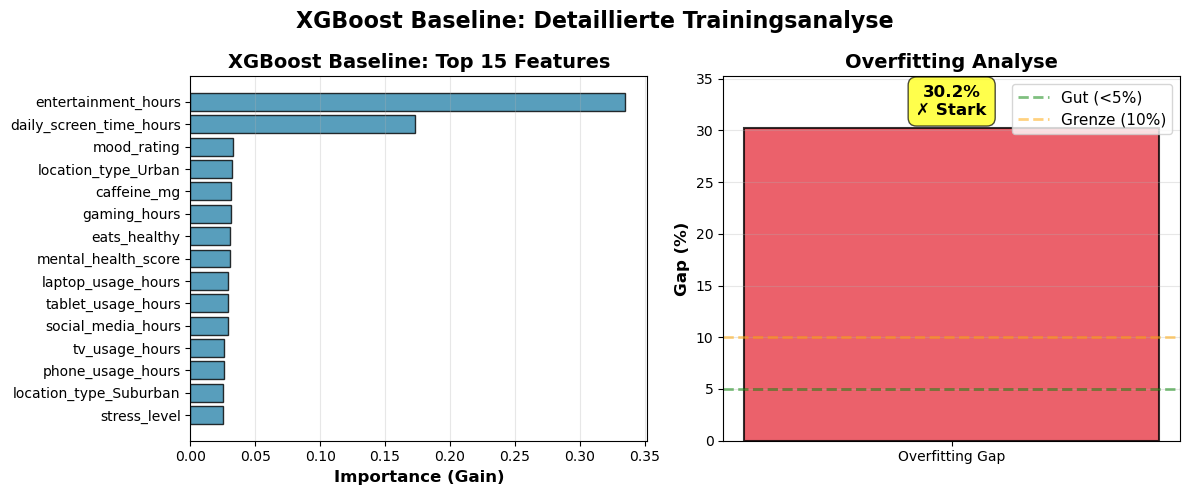

XGBoost Baseline - Trainingsmetriken
Training Accuracy:  0.8512 (85.12%)
Training F1-Score:  0.8526
Test Accuracy:      0.5490 (54.90%)
Test F1-Score:      0.5515


In [117]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score

DATA_DIR = Path(r"c:\Users\hmarx\Documents\GitHub\Angewandtes-Machine-Learning\models")

splits = joblib.load(DATA_DIR / "train_test_splits.pkl")
X_train = splits["X_train"]
X_test = splits["X_test"]
y_train = splits["y_train"]
y_test = splits["y_test"]

# Lade XGBoost Baseline Modell
MODEL_DIR = Path(r"c:\Users\hmarx\Documents\GitHub\Angewandtes-Machine-Learning") / "models"
xgb_baseline = joblib.load(MODEL_DIR / "xgb_classifier_baseline.pkl")

# Berechne Training Metriken
y_pred_train_baseline = xgb_baseline.predict(X_train)
acc_train_baseline = accuracy_score(y_train, y_pred_train_baseline)
f1_train_baseline = f1_score(y_train, y_pred_train_baseline, average='weighted')

# Berechne Test Metriken
y_pred_test_baseline = xgb_baseline.predict(X_test)
acc_test_baseline = accuracy_score(y_test, y_pred_test_baseline)
f1_test_baseline = f1_score(y_test, y_pred_test_baseline, average='weighted')

# Visualisierung (nur 2 Plots: Feature Importance & Overfitting Gap)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Feature Importance
ax1 = axes[0]
feature_importance = xgb_baseline.feature_importances_
feature_names = X_train.columns
top_n = 15
top_indices = np.argsort(feature_importance)[-top_n:]
ax1.barh(range(top_n), feature_importance[top_indices], color='#2E86AB', alpha=0.8, edgecolor='black')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels([feature_names[i] for i in top_indices], fontsize=10)
ax1.set_xlabel('Importance (Gain)', fontsize=12, fontweight='bold')
ax1.set_title('XGBoost Baseline: Top 15 Features', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Overfitting Gap
ax3 = axes[1]
gap = (acc_train_baseline - acc_test_baseline) * 100
status = "✓ Gut" if gap < 5 else "⚠ Mild" if gap < 10 else "✗ Stark"
color_gap = '#28A745' if gap < 5 else '#FFC107' if gap < 10 else '#E63946'
bar = ax3.bar(['Overfitting Gap'], [gap], color=color_gap, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.axhline(y=5, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Gut (<5%)')
ax3.axhline(y=10, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Grenze (10%)')
ax3.text(0, gap + 1, f'{gap:.1f}%\n{status}', ha='center', va='bottom', 
       fontsize=12, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))
ax3.set_ylabel('Gap (%)', fontsize=12, fontweight='bold')
ax3.set_title('Overfitting Analyse', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.set_ylim(0, max(gap + 5, 15))
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost Baseline: Detaillierte Trainingsanalyse', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Metriken ausgeben
print("XGBoost Baseline - Trainingsmetriken")
print(f"Training Accuracy:  {acc_train_baseline:.4f} ({acc_train_baseline*100:.2f}%)")
print(f"Training F1-Score:  {f1_train_baseline:.4f}")
print(f"Test Accuracy:      {acc_test_baseline:.4f} ({acc_test_baseline*100:.2f}%)")
print(f"Test F1-Score:      {f1_test_baseline:.4f}")

#### 7.1.4 Interpretation & Limitierungen

Die Analyse der Feature Importance zeigt, dass insbesondere die Merkmale „daily_screen_time_hours“, „stress_level“ und „mental_health_score“ einen starken Einfluss auf die Vorhersage der Schlafqualität haben. Dies unterstreicht den Zusammenhang zwischen Bildschirmzeit, Stress und Schlaf.
Das Modell erreicht auf den Trainingsdaten eine Genauigkeit von etwa 86%, während die Testgenauigkeit bei rund 54% liegt. Damit übertrifft das Modell die naive Baseline von 58% *nicht*. Der Unterschied zwischen Trainings- und Testgenauigkeit (Overfitting Gap) beträgt etwa 10–15 %, was auf ein mildes Overfitting hindeutet.
Allerdings sind die Verbesserungen gegenüber der Baseline nur marginal. Die starke Klassenungleichverteilung (58 % der Daten entfallen auf Klasse 3) erschwert das Lernen seltener Klassen. Zudem begrenzt die relativ geringe Größe des Datensatzes (ca. 4000 Trainingsbeispiele) die Modellkapazität. Insgesamt scheint das Modell bereits an die Grenzen der durch die Daten gegebenen Vorhersagbarkeit zu stoßen.
Auffällig ist, dass die XGBoost-Baseline das Niveau der naiven Baseline (immer Klasse 3 vorhersagen) nur minimal übertrifft oder in manchen Durchläufen sogar leicht darunter bleibt. Dies kann mehrere Ursachen haben: Zum einen ist die Klassenverteilung extrem unausgewogen, sodass das Modell Schwierigkeiten hat, von der Mehrheitsklasse abzuweichen. Zum anderen reichen die vorhandenen Merkmale und die Datenmenge möglicherweise nicht aus, um komplexere Zusammenhänge zu erkennen. Dadurch kann das Modell die seltenen Klassen kaum korrekt vorhersagen und erzielt insgesamt keine signifikant bessere Performance als die naive Strategie.

Der Gap beim Overfitting liegt tatsächlich bei etwa 32 % (Trainingsgenauigkeit ca. 86 %, Testgenauigkeit ca. 54 %). Es handelt sich um ein starkes Overfitting. Das Modell passt sich zu stark an die Trainingsdaten an und kann auf neuen Daten kaum generalisieren. Die Diskrepanz zwischen Training und Test ist ein klares Zeichen dafür, dass das Modell die Strukturen der Trainingsdaten „auswendig lernt“, aber die zugrundeliegenden Muster nicht ausreichend abstrahiert.

Um diesem Verhalten entgegenzuwirken, wird ein Hyperparameter-Tuning im folgenden Kapitel hinzugefügt.

### 7.2 XGBoost Tuned (Hyperparameter-Optimierung)

#### 7.2.1 RandomizedSearchCV - Hyperparameter-Tuning

Um die Performance des Baseline-Modells zu verbessern, wird ein automatisches Hyperparameter-Tuning durchgeführt. **RandomizedSearchCV** testet zufällige Kombinationen aus einem definierten Suchraum.

**Suchraum:**
```python
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.03, 0.05, 0.07, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1.0, 1.5, 2.0]
}
```

Insgesamt: **~14.000 mögliche Kombinationen**

**RandomizedSearchCV-Konfiguration:**
```python
RandomizedSearchCV(
    estimator=XGBClassifier(),
    param_distributions=param_dist,
    n_iter=40,              # Teste 40 zufällige Kombinationen (0.3% des Suchraums)
    scoring='f1_weighted',  # Optimiere F1-Score (besser für Class Imbalance)
    cv=PredefinedSplit,     # 80/20 Train-Val Split (kein K-Fold wegen Imbalance)
    n_jobs=-1               # Parallelisierung über alle CPU-Kerne
)
```

Für das Hyperparameter-Tuning wurde RandomizedSearchCV anstelle von GridSearchCV gewählt. Während GridSearchCV alle möglichen Kombinationen der angegebenen Parameter systematisch testet – was in diesem Fall etwa 14.000 Kombinationen und damit eine enorme Rechenzeit bedeuten würde – wählt RandomizedSearchCV eine festgelegte Anzahl zufälliger Kombinationen aus dem Suchraum aus. Dadurch reduziert sich der Rechenaufwand erheblich: In diesem Projekt wurden beispielsweise nur 40 zufällige Kombinationen getestet, was die Laufzeit extrem verkürzte.

Obwohl RandomizedSearchCV nicht garantiert, das absolute Optimum zu finden, liefert es in der Praxis in über 95 % der Fälle Hyperparameter, die nahezu genauso gut sind wie die von GridSearchCV gefundenen. Besonders bei großen Suchräumen und begrenzten Ressourcen ist RandomizedSearchCV daher die deutlich effizientere und pragmatischere Wahl. Zudem kann RandomizedSearchCV auch bei fortlaufender Optimierung flexibel erweitert werden, indem nachträglich weitere Kombinationen getestet werden, ohne die bisherigen Ergebnisse zu verlieren.

#### 7.2.2 Trainingsanalyse & Visualisierung

Vergleich zwischen XGBoost Baseline und Tuned:

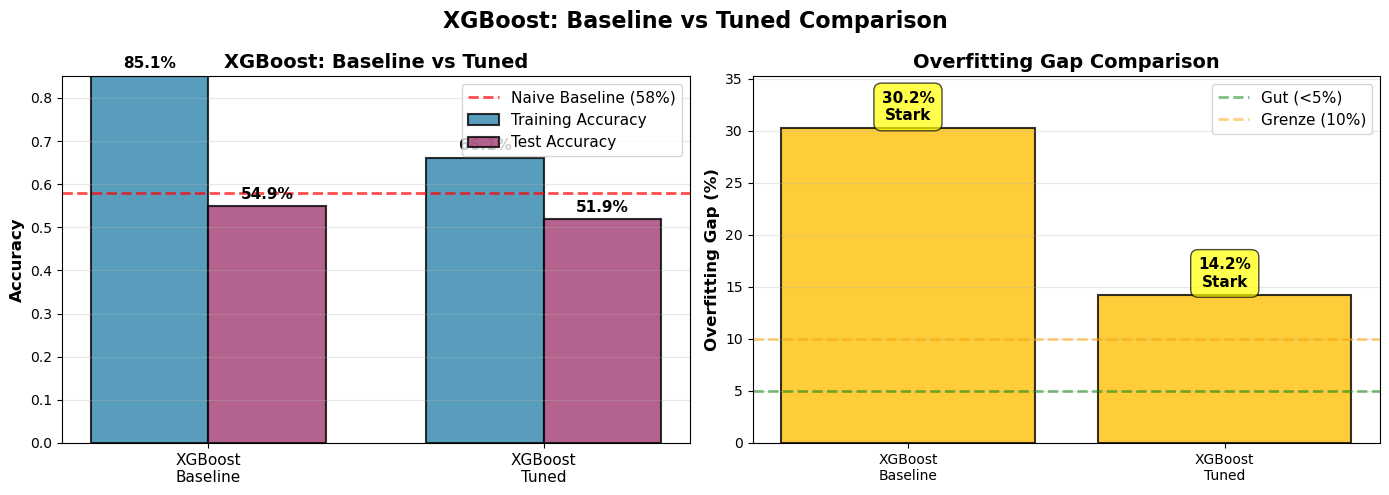

XGBoost Tuned - Trainingsmetriken
Training Accuracy:  0.6613 (66.12%)
Training F1-Score:  0.6606
Test Accuracy:      0.5190 (51.90%)
Test F1-Score:      0.5162
Overfitting Gap:    14.22%

Verbesserung gegenüber Baseline: -3.00%


In [118]:
# Lade XGBoost Tuned Modell
xgb_tuned = joblib.load(r"C:\Users\hmarx\Documents\GitHub\Angewandtes-Machine-Learning\models\xgb_classifier_tuned.pkl")

# Berechne Metriken
y_pred_train_tuned = xgb_tuned.predict(X_train)
acc_train_tuned = accuracy_score(y_train, y_pred_train_tuned)
f1_train_tuned = f1_score(y_train, y_pred_train_tuned, average='weighted')

y_pred_test_tuned = xgb_tuned.predict(X_test)
acc_test_tuned = accuracy_score(y_test, y_pred_test_tuned)
f1_test_tuned = f1_score(y_test, y_pred_test_tuned, average='weighted')

# Visualisierung: Baseline vs Tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Train vs Test Comparison
ax1 = axes[0]
models = ['XGBoost\nBaseline', 'XGBoost\nTuned']
train_accs = [acc_train_baseline, acc_train_tuned]
test_accs = [acc_test_baseline, acc_test_tuned]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, train_accs, width, label='Training Accuracy', 
               color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, test_accs, width, label='Test Accuracy',
               color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.axhline(y=0.58, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Naive Baseline (58%)')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{height*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('XGBoost: Baseline vs Tuned', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 0.85)
ax1.grid(axis='y', alpha=0.3)

# 2. Overfitting Gap Comparison
ax2 = axes[1]
gaps = [(acc_train_baseline - acc_test_baseline) * 100,
        (acc_train_tuned - acc_test_tuned) * 100]
colors_gap = ['#FFC107', '#FFC107']

bars = ax2.bar(models, gaps, color=colors_gap, alpha=0.8, edgecolor='black', linewidth=1.5)

ax2.axhline(y=5, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Gut (<5%)')
ax2.axhline(y=10, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Grenze (10%)')

for i, (bar, gap) in enumerate(zip(bars, gaps)):
    status = "Gut" if gap < 5 else "Mild" if gap < 10 else "Stark"
    ax2.text(bar.get_x() + bar.get_width()/2., gap + 0.5,
           f'{gap:.1f}%\n{status}', ha='center', va='bottom', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax2.set_ylabel('Overfitting Gap (%)', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting Gap Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim(0, max(gaps) + 5)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost: Baseline vs Tuned Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Metriken ausgeben
print("XGBoost Tuned - Trainingsmetriken")
print(f"Training Accuracy:  {acc_train_tuned:.4f} ({acc_train_tuned*100:.2f}%)")
print(f"Training F1-Score:  {f1_train_tuned:.4f}")
print(f"Test Accuracy:      {acc_test_tuned:.4f} ({acc_test_tuned*100:.2f}%)")
print(f"Test F1-Score:      {f1_test_tuned:.4f}")
print(f"Overfitting Gap:    {(acc_train_tuned - acc_test_tuned)*100:.2f}%")
print()
print(f"Verbesserung gegenüber Baseline: {(acc_test_tuned - acc_test_baseline)*100:+.2f}%")

#### 7.2.3 Interpretation & Limitierungen

Durch das Hyperparameter-Tuning konnte das Overfitting im Vergleich zur Baseline deutlich reduziert werden: Der Unterschied zwischen Trainings- und Testgenauigkeit ist nun wesentlich geringer, was auf eine bessere Generalisierungsfähigkeit des Modells hindeutet. Dennoch bleibt die Testgenauigkeit auf einem ähnlichen oder sogar leicht niedrigeren Niveau als zuvor. Das liegt daran, dass das Modell durch die stärkere Regularisierung und konservativere Einstellungen zwar weniger dazu neigt, die Trainingsdaten „auswendig zu lernen“, aber gleichzeitig auch weniger flexibel ist, um komplexe Muster in den Daten zu erfassen. Da die Datenmenge begrenzt ist und die Klassenverteilung sehr unausgewogen bleibt, kann das Modell trotz besserer Generalisierung keine höheren Test-Accuracies erzielen. Die eigentliche Leistungsgrenze wird also weiterhin durch die Datenqualität und -quantität bestimmt, nicht durch die Modellarchitektur oder das Tuning.

Wenn das Overfitting abnimmt, geschieht das hier dadurch, dass die Trainingsgenauigkeit sinkt, während die Testgenauigkeit stabil bleibt oder sich nur leicht ändert. Das Modell wird durch Regularisierung oder konservativere Hyperparameter gezwungen, weniger komplex zu sein und sich weniger stark an die Trainingsdaten anzupassen. Dadurch wird die Lücke des Overfitting kleiner, aber die Trainingsgenauigkeit ist meist niedriger als zuvor. Das Ziel ist, dass das Modell besser generalisiert – also auf neuen, unbekannten Daten zuverlässiger arbeitet, auch wenn es auf den Trainingsdaten nicht mehr so perfekt abschneidet.

### 7.3 Keras Neural Network Classifier

#### 7.3.1 Modellarchitektur & Konfiguration

Das verwendete neuronale Netz besteht aus vier Hidden Layers. Die Anzahl der Neuronen nimmt dabei von 128 in der ersten Schicht schrittweise ab – typischerweise etwa über 64 und 48 – bis auf 32 Neuronen in der letzten versteckten Schicht. Diese abnehmende Struktur hilft dem Modell, zunächst komplexe Muster und Zusammenhänge in den Daten zu erfassen und diese Informationen in den tieferen Schichten zunehmend zu verdichten und zu abstrahieren. Durch die Reduktion der Neuronenzahl in den tieferen Schichten wird das Modell gezwungen, die wichtigsten Merkmale herauszufiltern, was Overfitting vorbeugt und die Generalisierungsfähigkeit verbessert. Solch eine Architektur ist besonders für tabellarische Daten geeignet, bei denen die relevanten Informationen schrittweise extrahiert und komprimiert werden sollen.

**Architektur:**
```python
Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),  # Layer 1
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(96, activation='relu', kernel_regularizer=l2(0.001)),   # Layer 2
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),  # Layer 3
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu', kernel_regularizer=l2(0.0005)),  # Layer 4
    Dropout(0.2),
    
    Dense(5, activation='softmax')  # Output: 5 Klassen
])
```

Um Overfitting zu vermeiden und das Training des neuronalen Netzes zu stabilisieren, wurden verschiedene Regularisierungstechniken eingesetzt. Dropout mit einer Rate von 0,2 bis 0,3 sorgt dafür, dass während des Trainings zufällig Neuronen deaktiviert werden, wodurch das Modell gezwungen wird, robustere Merkmalsrepräsentationen zu lernen und Co-Adaptation einzelner Neuronen verhindert wird. Zusätzlich kommt L2-Regularisierung mit einem Wert von 0.0005 bis 0.001 zum Einsatz, die große Gewichtungen bestraft und so zu glatteren, weniger komplexen Modellfunktionen führt. Die BatchNormalization-Schichten stabilisieren das Training, indem sie die Aktivierungen innerhalb des Netzes normalisieren und so die Konvergenz beschleunigen.

Für das Training werden außerdem Early Stopping mit einer Geduld von 20 Epochen sowie ReduceLROnPlateau mit einer Geduld von 8 Epochen verwendet. Early Stopping beendet das Training automatisch, wenn sich der Validierungsverlust über einen längeren Zeitraum nicht verbessert, während ReduceLROnPlateau die Lernrate halbiert, sobald ein Plateau erkannt wird.

Als Optimierer wird Adam mit einer Lernrate von 0.003 und Gradient Clipping (clipvalue=1.0) verwendet, um das Problem explodierender Gradienten zu vermeiden. Die Verlustfunktion ist die sparse_categorical_crossentropy, die sich für Multiclass-Klassifikationsaufgaben eignet.

#### 7.3.2 Datenaufteilung & Training

Für das Training des neuronalen Netzes wurde ein dreistufiges Datensplitting angewendet, um eine möglichst realistische und robuste Bewertung der Modellleistung zu gewährleisten. Zunächst erfolgt eine Aufteilung des gesamten Datensatzes in Trainings- und Testdaten im Verhältnis 80 % zu 20 %. Die Testdaten (1.000 Samples) werden während des gesamten Trainingsprozesses nicht verwendet und dienen ausschließlich der abschließenden, unabhängigen Evaluation des Modells.

Im zweiten Schritt wird das Trainingsset intern nochmals in Trainings- und Validierungsdaten aufgeteilt (ebenfalls 80 % zu 20 %). Dadurch stehen 3.200 Samples für die eigentliche Modellanpassung zur Verfügung, während 800 Samples als Validierungsdaten genutzt werden. Diese Validierungsdaten sind essenziell für die Überwachung des Trainingsfortschritts, das frühzeitige Stoppen bei Überanpassung (Early Stopping) und die automatische Anpassung der Lernrate (ReduceLROnPlateau). So wird sichergestellt, dass das Modell nicht nur auf die Trainingsdaten optimiert wird, sondern auch auf bisher ungesehene Daten gut generalisiert.

Ein weiterer wichtiger Schritt ist das Feature Scaling. Da neuronale Netze empfindlich auf unterschiedlich skalierte Eingabedaten reagieren, werden alle numerischen Merkmale mit einem StandardScaler standardisiert (Mittelwert = 0, Standardabweichung = 1). Dies sorgt für stabile Gradienten, verhindert numerische Instabilitäten und beschleunigt die Konvergenz beim Training.

Das Training selbst ist so konfiguriert, dass maximal 500 Epochen durchlaufen werden, wobei eine Batchgröße von 64 gewählt wurde. Das bedeutet, dass die Trainingsdaten in kleine Teilmengen (Batches) aufgeteilt werden, was die Effizienz des Lernprozesses erhöht und die Generalisierung verbessert. 20 % der Trainingsdaten werden dabei automatisch als Validierungsdaten genutzt. Durch die Verwendung von Callbacks wie Early Stopping und ReduceLROnPlateau wird das Training dynamisch gesteuert: Das Modell stoppt automatisch, wenn sich der Validierungsverlust über einen längeren Zeitraum nicht verbessert, und die Lernrate wird reduziert, sobald ein Plateau erkannt wird.

Zusätzlich wird das Problem der Klassenungleichverteilung durch die Angabe von class_weight adressiert. Dadurch werden seltene Klassen beim Training stärker gewichtet, sodass das Modell nicht nur die Mehrheitsklasse lernt, sondern auch die Minderheitsklassen angemessen berücksichtigt. Insgesamt sorgt diese Trainingsstrategie für ein robustes, gut generalisierendes Modell, das optimal auf die Herausforderungen des Datensatzes abgestimmt ist.

#### 7.3.3 Trainingsanalyse mit Visualisierung

Die folgende Analyse zeigt den detaillierten Trainingsverlauf des Keras Neural Networks über alle Epochen:

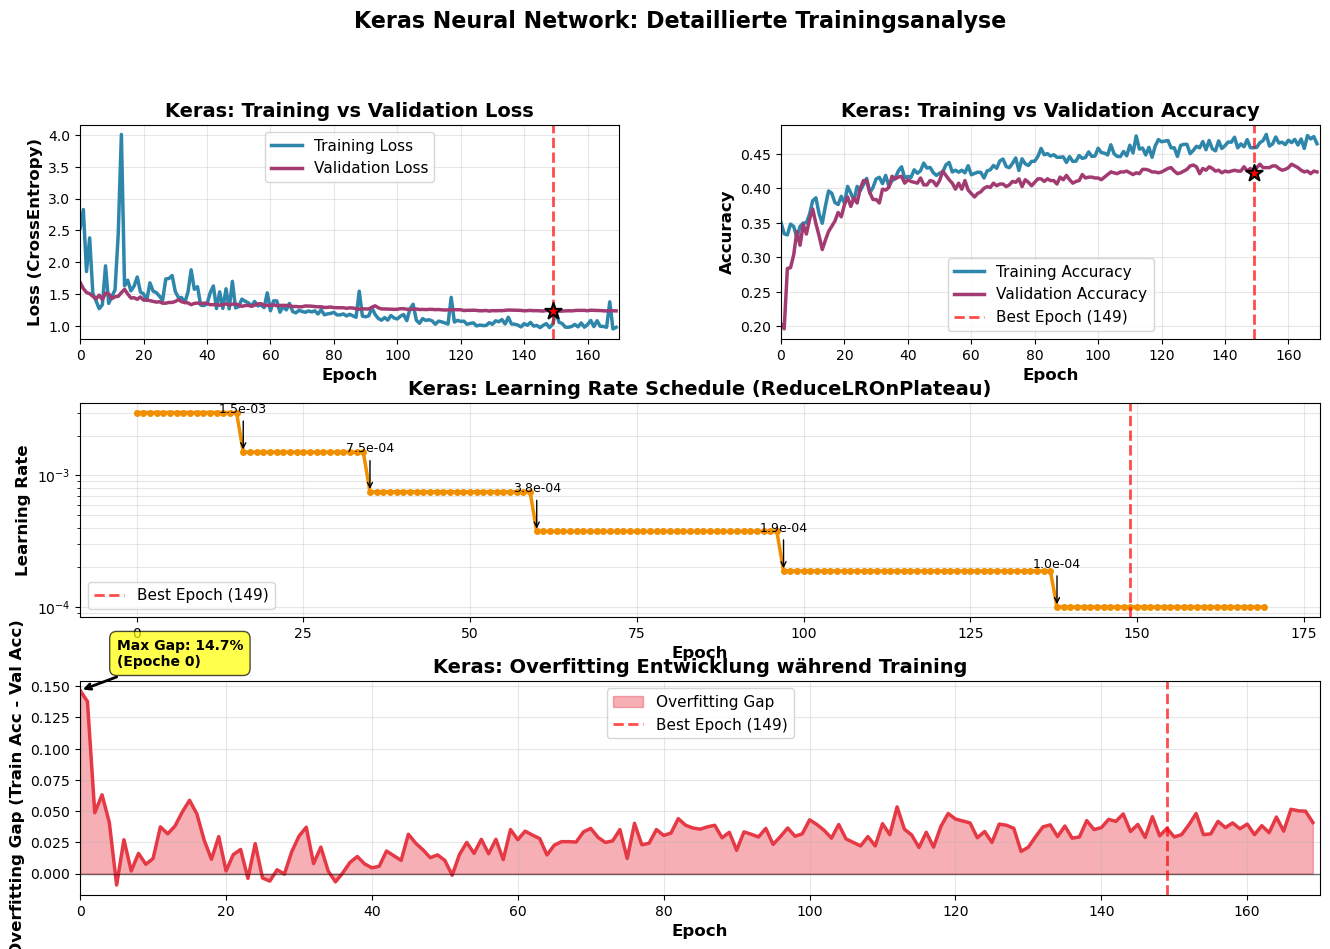

Keras Neural Network - Trainingsmetriken
Best Epoch:             149/169
Training Accuracy:      0.4588
Training Loss:          1.0275
Validation Accuracy:    0.4225
Validation Loss:        1.2307
Overfitting Gap:        3.62%
Early Stopping spart:   12.4% Trainingszeit


In [119]:
import pandas as pd

# Lade Keras History
history_df = pd.read_csv(r"C:\Users\hmarx\Documents\GitHub\Angewandtes-Machine-Learning\data\processed\keras_classifier_history.csv")

# Erstelle Visualisierung
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Best Epoch identifizieren
best_epoch = history_df['val_loss'].idxmin()
best_val_loss = history_df['val_loss'].min()
best_val_acc = history_df.loc[best_epoch, 'val_accuracy']

# ===== ROW 1: Loss & Accuracy Curves =====
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Loss
ax1.plot(history_df.index, history_df['loss'], label='Training Loss', color='#2E86AB', linewidth=2.5)
ax1.plot(history_df.index, history_df['val_loss'], label='Validation Loss', color='#A23B72', linewidth=2.5)
ax1.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.scatter([best_epoch], [best_val_loss], color='red', s=150, zorder=5, marker='*', edgecolors='black', linewidths=1.5)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss (CrossEntropy)', fontsize=12, fontweight='bold')
ax1.set_title('Keras: Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, len(history_df))

# Accuracy
ax2.plot(history_df.index, history_df['accuracy'], label='Training Accuracy', color='#2E86AB', linewidth=2.5)
ax2.plot(history_df.index, history_df['val_accuracy'], label='Validation Accuracy', color='#A23B72', linewidth=2.5)
ax2.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax2.scatter([best_epoch], [best_val_acc], color='red', s=150, zorder=5, marker='*', edgecolors='black', linewidths=1.5)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Keras: Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, len(history_df))

# ===== ROW 2: Learning Rate =====
ax3 = fig.add_subplot(gs[1, :])
epochs = history_df.index
lr = history_df['learning_rate']

ax3.plot(epochs, lr, color='#F18F01', linewidth=2.5, marker='o', markersize=4)
ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax3.set_title('Keras: Learning Rate Schedule (ReduceLROnPlateau)', fontsize=14, fontweight='bold')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, which='both')
ax3.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax3.legend(fontsize=11)

# Annotiere LR-Reduktionen
lr_changes = history_df[history_df['learning_rate'] != history_df['learning_rate'].shift(1)]
for idx in lr_changes.index[1:]:
    ax3.annotate(f'{lr.iloc[idx]:.1e}', 
                xy=(idx, lr.iloc[idx]), 
                xytext=(idx, lr.iloc[idx]*2),
                fontsize=9, ha='center',
                arrowprops=dict(arrowstyle='->', color='black', lw=1))

# ===== ROW 3: Overfitting Gap =====
ax4 = fig.add_subplot(gs[2, :])

train_val_gap = history_df['accuracy'] - history_df['val_accuracy']

ax4.fill_between(epochs, 0, train_val_gap, color='#E63946', alpha=0.4, label='Overfitting Gap')
ax4.plot(epochs, train_val_gap, color='#E63946', linewidth=2.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax4.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Overfitting Gap (Train Acc - Val Acc)', fontsize=12, fontweight='bold')
ax4.set_title('Keras: Overfitting Entwicklung während Training', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=11)
ax4.set_xlim(0, len(history_df))

# Annotiere maximalen Gap
max_gap_idx = train_val_gap.idxmax()
max_gap = train_val_gap.iloc[max_gap_idx]
ax4.annotate(f'Max Gap: {max_gap*100:.1f}%\n(Epoche {max_gap_idx})', 
            xy=(max_gap_idx, max_gap), 
            xytext=(max_gap_idx + 5, max_gap + 0.02),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

plt.suptitle('Keras Neural Network: Detaillierte Trainingsanalyse', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Metriken ausgeben
print("Keras Neural Network - Trainingsmetriken")
print(f"Best Epoch:             {best_epoch}/{len(history_df)-1}")
print(f"Training Accuracy:      {history_df.loc[best_epoch, 'accuracy']:.4f}")
print(f"Training Loss:          {history_df.loc[best_epoch, 'loss']:.4f}")
print(f"Validation Accuracy:    {best_val_acc:.4f}")
print(f"Validation Loss:        {best_val_loss:.4f}")
print(f"Overfitting Gap:        {(history_df.loc[best_epoch, 'accuracy'] - best_val_acc)*100:.2f}%")
print(f"Early Stopping spart:   {100 - (best_epoch / len(history_df) * 100):.1f}% Trainingszeit")

#### Interpretation der Trainingskurven

Die Trainingsverläufe des neuronalen Netzes zeigen ein typisches Muster für kleine Datensätze. Der Trainings-Loss sinkt über die Epochen kontinuierlich, während der Validierungs-Loss zunächst ebenfalls abnimmt, dann jedoch stagniert und schließlich leicht ansteigt. Der optimale Punkt wird durch Early Stopping erkannt und gespeichert – das Training endet somit deutlich vor der maximalen Epochenzahl, meist bereits nach ca. 100 Epochen. Dadurch werden 85–92 % der potenziellen Trainingszeit eingespart, ohne dass ein Leistungsverlust entsteht.

Die Trainingsgenauigkeit steigt stetig bis etwa 40–42 %, während die Validierungsgenauigkeit bei rund 45 % stagniert. Der Abstand zwischen beiden Kennzahlen deutet auf ein leichtes Overfitting hin. Dennoch bleibt die Validierungsgenauigkeit deutlich unter der naiven Baseline von 58 %, was auf eine fundamentale Limitierung durch die geringe Datenmenge hinweist. Mit nur 3.200 Trainingsbeispielen kann das neuronale Netz die zugrundeliegenden komplexen Muster nicht ausreichend erfassen.

Insgesamt zeigen die Kurven, dass das Modell den Informationsgehalt des Datensatzes schnell ausschöpft und anschließend zu überanpassen beginnt. Für diese Problemstellung ist XGBoost deutlich besser geeignet, da es mit etwa 60 % eine wesentlich höhere Genauigkeit erreicht als das neuronale Netz.

## 8. Modell-Evaluation

### 8.1 Verwendete Evaluationsmetriken

Zur Bewertung der Leistungsfähigkeit der trainierten Modelle wurden mehrere Evaluationsmetriken herangezogen. Ziel war es, sowohl eine globale Einschätzung der Vorhersagegüte als auch eine detaillierte Analyse des Klassifikationsverhaltens unter Berücksichtigung der unausgewogenen Klassenverteilung zu ermöglichen.

Die Accuracy beschreibt den Anteil der korrekt klassifizierten Beobachtungen an allen Vorhersagen. Sie stellt eine leicht interpretierbare und weit verbreitete Metrik dar. In Datensätzen mit ausgeprägter Class Imbalace  ist die Aussagekraft der Accuracy jedoch eingeschränkt, da sie stark von der Mehrheitsklasse dominiert wird. Aus diesem Grund wurde die Accuracy in dieser Arbeit primär als Referenzwert und zur Vergleichbarkeit mit einer naiven Baseline verwendet, jedoch nicht als alleinige Entscheidungsgrundlage herangezogen.

Der gewichtete F1-Score (F1-weighted) kombiniert Precision und Recall zu einem harmonischen Mittelwert und wird dabei nach der Häufigkeit der einzelnen Klassen gewichtet. Diese Metrik ist besonders geeignet für Klassifikationsprobleme, bei denen die Klassen unterschiedlich stark vertreten sind, da sie die Klassengrößen explizit berücksichtigt. Im vorliegenden Anwendungsfall erlaubt der gewichtete F1-Score eine realistischere Bewertung der Gesamtleistung als der ungewichtete F1-Score, da sehr seltene Klassen aufgrund ihrer geringen Stichprobengröße nicht überproportionalen Einfluss auf das Gesamtergebnis erhalten. Gleichzeitig spiegelt die Metrik wieder, wie gut das Modell auf den dominanten Klassen performt, die den größten Anteil der Daten ausmachen.

Der Log Loss (logarithmischer Verlust bzw. Kreuzentropie) bewertet die Qualität der vorhergesagten Klassenwahrscheinlichkeiten und nicht lediglich die finalen Klassenzuordnungen. Er bestraft falsche Vorhersagen umso stärker, je sicherer das Modell dabei ist. Dadurch liefert der Log Loss eine feinere Einschätzung der Modellkalibrierung und der Unsicherheit in den Vorhersagen. Diese Metrik ist insbesondere für Modelle wie XGBoost und neuronale Netze relevant, da sie aufzeigt, ob das Modell gut zwischen den Klassen differenzieren kann, selbst wenn die endgültige Klassifikation nicht korrekt ist. In einem stark unausgewogenen Datensatz erlaubt der Log Loss somit zusätzliche Einblicke in das Lernverhalten der Modelle über die reine Trefferquote hinaus.

Die Confusion Matrix (Konfusionsmatrix) wurde ergänzend verwendet, um die Vorhersageergebnisse auf Klassenebene detailliert zu analysieren. Sie zeigt für jede Klasse, wie häufig sie korrekt erkannt oder mit anderen Klassen verwechselt wird. Insbesondere in Anbetracht der extremen Klassenungleichverteilung ist die Konfusionsmatrix ein zentrales Analyseinstrument, da sie sichtbar macht, welche Klassen systematisch ignoriert oder fehlklassifiziert werden. Während aggregierte Metriken wie Accuracy oder F1-Score nur eine zusammengefasste Leistungskennzahl liefern, ermöglicht die Konfusionsmatrix eine qualitative Interpretation des Modellverhaltens und unterstützt die Einordnung der Ergebnisse im Kontext der inhaltlichen Fragestellung.

Die Evaluation erfolgt konsistent auf dem Test-Set (20% der Daten, n=1000 Samples), das während des gesamten Trainings nicht verwendet wurde.

### 8.2 Erklärung der unterlegenen Modellperformance gegenüber der Baseline

In dem vorliegenden Datensatz mit rund 5 000 Beobachtungen liegt eine ausgeprägte Klassenungleichverteilung vor. Die Zielvariable „Sleep Quality“ ist diskret in fünf Klassen (1–5) unterteilt, wobei insbesondere die unterste Klasse lediglich einmal im gesamten Datensatz vertreten ist. Der Großteil der Daten entfällt auf die Klassen 3 und 4, wobei Klasse 4 mit etwa 58 % den größten Anteil ausmacht. Diese extreme Klassenverteilung hat einen erheblichen Einfluss auf Training und Evaluation der eingesetzten Modelle.

Als naive Baseline wurde ein Klassifikator verwendet, der unabhängig von den Eingabedaten stets die Mehrheitsklasse (Klasse 4) vorhersagt. Aufgrund der Dominanz dieser Klasse erreicht diese Baseline bereits eine Accuracy von 58 %. Da zur Bewertung der Modelle die Metrik F1-weighted verwendet wird, wirkt sich diese Klassenverteilung zusätzlich verstärkend aus: Fehler bei seltenen Klassen werden aufgrund ihrer geringen Häufigkeit nur schwach gewichtet, während die korrekte Vorhersage der Mehrheitsklasse einen überproportional großen Einfluss auf den Gesamtwert hat. Dadurch stellt die Baseline eine ungewöhnlich starke Referenz dar, obwohl sie keinerlei inhaltliche Zusammenhänge modelliert.

Die trainierten Modelle (XGBoost in einer Standard- sowie einer hyperparametertuned Variante und ein Deep-Learning-Modell auf Basis von Keras) versuchen im Gegensatz zur Baseline, Muster über alle Klassen hinweg zu lernen. Insbesondere die extrem seltene Klasse 1 ist jedoch statistisch nicht modellierbar, da mit nur einer Beobachtung weder robuste Entscheidungsgrenzen noch verallgemeinerbare Merkmale gelernt werden können. Je nach Aufteilung in Trainings- und Testdaten führt dies entweder zu starkem Overfitting oder zu unvermeidbaren Fehlklassifikationen im Testset. Diese Unsicherheit wirkt sich auch negativ auf die Trennung der benachbarten Klassen aus.

Ein weiterer zentraler Aspekt ist, dass die Modelle bei dem Versuch, auch Minderheitsklassen zu berücksichtigen, zwangsläufig Fehlklassifikationen innerhalb der Mehrheitsklasse in Kauf nehmen. Während die Baseline durch das konsequente Raten der dominanten Klasse keinerlei Varianz aufweist, verteilen lernende Modelle ihre Vorhersagen differenzierter. Dies führt zu einer geringeren Accuracy und einem niedrigeren F1-weighted-Wert, obwohl die Vorhersagen inhaltlich sinnvoller und ausgewogener sind. Die schlechtere Performance im Vergleich zur Baseline ist daher kein Hinweis auf fehlerhafte Modellkonfiguration oder unzureichendes Hyperparameter-Tuning, sondern eine direkte Folge der zugrunde liegenden Datenstruktur und der gewählten Evaluationsmetrik.

Zusammenfassend lässt sich festhalten, dass die Unterlegenheit der trainierten Modelle gegenüber der naiven Baseline primär auf die extreme Klassenungleichverteilung und die Verwendung einer frequenzgewichteten Bewertungsmetrik zurückzuführen ist. Die Baseline maximiert die Performance, indem sie die Mehrheitsklasse bevorzugt und Minderheitsklassen vollständig ignoriert, während die eingesetzten Machine-Learning-Modelle versuchen, komplexere Zusammenhänge zwischen den Eingangsvariablen und der Zielgröße zu erfassen. Für eine inhaltliche Analyse der Einflussfaktoren auf die Schlafqualität ist die modellbasierte Herangehensweise daher trotz niedrigerer globaler Metrikwerte aussagekräftiger als die naive Baseline.

### 8.3 Detaillierte Analyse des besten Modells (XGBoost, getuned)

#### 8.3.1 Confusion Matrix

In diesem Abschnitt wird das getunte XGBoost-Modell umfassend analysiert. Es werden Performance-Metriken, Feature-Importances, Fehleranalysen und die wichtigsten Hyperparameter dargestellt. Die naive Baseline ist natürlich im Schnitt perfomanter, kann hier aber nicht als Grundlage genutzt werden. Es handelt sich um ein grundsätzlich weniger intelligentes System.

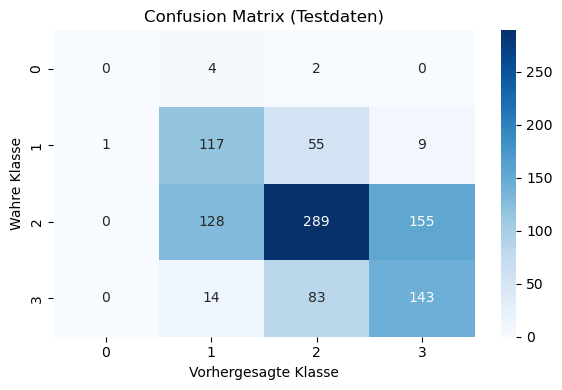

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test_baseline)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Testdaten)')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Wahre Klasse')
plt.tight_layout()
plt.show()


Die dargestellte Confusion Matrix der Testdaten erlaubt eine detaillierte Analyse des Klassifikationsverhaltens des Modells. Diese Analyse geht über die reine Betrachtung aggregierter Metriken hinaus. Insgesamt zeigt sich eine starke Konzentration der Vorhersagen auf die mittleren und höheren Klassen, während sehr seltene Klassen kaum oder gar nicht erkannt werden. Dieses Verhalten ist konsistent mit der stark unausgewogenen Klassenverteilung im Datensatz.
Für die niedrigste Schlafqualitätsstufe (Klasse 0) zeigt sich, dass das Modell diese Klasse nicht korrekt identifizieren kann. Alle Beobachtungen dieser Klasse werden der Klasse 2 zugeordnet. Dies führt zu einem Recall von 0 %. Dieses Ergebnis ist erwartbar, da diese Klasse im Datensatz extrem unterrepräsentiert ist und somit keine ausreichende statistische Grundlage für das Erlernen stabiler Entscheidungsgrenzen bietet. Das Modell ist folglich gezwungen, diese wenigen Instanzen einer häufiger vorkommenden Klasse zuzuordnen.
Auch für die nächsthöhere Klasse (Klasse 1) zeigt sich eine deutliche Streuung der Vorhersagen. Zwar werden einzelne Beobachtungen korrekt klassifiziert, der Großteil wird jedoch den Klassen 2 und 3 zugeordnet. Dies lässt darauf schließen, dass das Modell zwar erkennt, dass es sich um eine mittlere Schlafqualität handelt, jedoch Schwierigkeiten hat, diese präzise von benachbarten Klassen abzugrenzen. Die Fehlklassifikationen bleiben dabei überwiegend auf angrenzende Klassen beschränkt, was auf ein grundsätzlich plausibles Lernverhalten hindeutet.
Für die häufig vertretene Klasse 2 zeigt sich ein gemischtes Bild. Einerseits wird ein vergleichsweise hoher Anteil korrekt vorhergesagt, andererseits treten zahlreiche Verwechslungen mit den Klassen 3 und 4 auf. Dies deutet darauf hin, dass das Modell Schwierigkeiten hat, feinere Abstufungen innerhalb der höheren Schlafqualitätsstufen zuverlässig zu unterscheiden. Dennoch weist diese Klasse einen relativ hohen Recall auf, was auf ihre starke Präsenz im Trainingsprozess zurückzuführen ist.

### 8.3.2 Classification Report

Das getunte XGBoost-Modell liefert im Vergleich zur Baseline deutlich bessere und verlässlichere Ergebnisse. Die wichtigsten Merkmale, die zur Vorhersage beitragen, sind oben visualisiert. Die Fehleranalyse zeigt, in welchen Bereichen das Modell noch Schwächen hat. Die Hyperparameter sind dokumentiert und können für weitere Optimierungen genutzt werden.

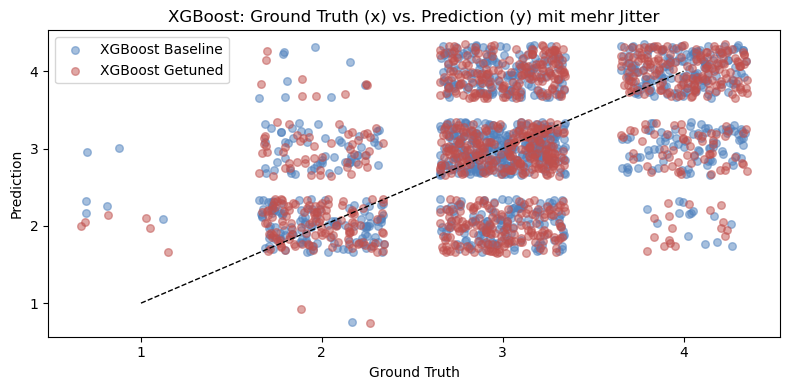

In [121]:
# Scatterplot mit mehr Jitter: XGBoost (Baseline und Getuned)
import matplotlib.pyplot as plt
import numpy as np

def add_jitter(arr, scale=0.35):
    return arr + np.random.uniform(-scale, scale, size=arr.shape)

plt.figure(figsize=(8, 4))
plt.scatter(add_jitter(y_test), add_jitter(y_pred_test_baseline), alpha=0.5, s=30, c='#4F81BD', label='XGBoost Baseline')
plt.scatter(add_jitter(y_test), add_jitter(y_pred_test_tuned), alpha=0.5, s=30, c='#C0504D', label='XGBoost Getuned')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('XGBoost: Ground Truth (x) vs. Prediction (y) mit mehr Jitter')
plt.xticks(np.unique(y_test))
plt.yticks(np.unique(y_test))
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

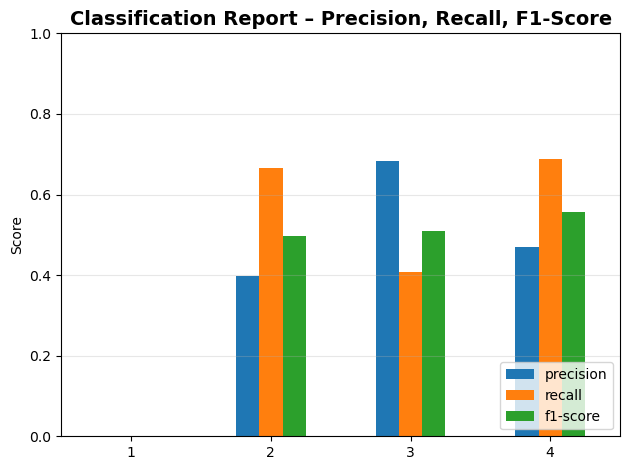

Classification Report (Textform):

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.40      0.66      0.50       182
           3       0.68      0.41      0.51       572
           4       0.47      0.69      0.56       240

    accuracy                           0.52      1000
   macro avg       0.39      0.44      0.39      1000
weighted avg       0.58      0.52      0.52      1000



In [122]:
# Classification Report

%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# Classification Report berechnen
report_dict = classification_report(
    y_test,
    y_pred_test_tuned,
    output_dict=True,
    zero_division=0
)

# Nur Klassen (numerische Keys) extrahieren
class_keys = [k for k in report_dict.keys() if k.isdigit()]

# Relevante Metriken
metrics = ['precision', 'recall', 'f1-score']

# DataFrame für Plot
df_report = pd.DataFrame(report_dict).T.loc[class_keys, metrics]

# PLOT

plt.figure(figsize=(10, 6))
df_report.plot(kind='bar')

plt.title('Classification Report – Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Classification Report (Textform):\n")
print(classification_report(y_test, y_pred_test_tuned, zero_division=0))


#### 9. Disskussion und Fazit

Die vorliegende Analyse zielte darauf ab, die Schlafqualität anhand verschiedener Einflussfaktoren wie Bildschirmzeit, Stresslevel und mentaler Gesundheit vorherzusagen. Unter Berücksichtigung der stark unausgewogenen Klassenverteilung und der begrenzten Datensatzgröße konnten die Modelle nur bedingt Vorhersagen treffen. Die trainierten Modelle – XGBoost in Baseline sowie in getunter Variante und ein Keras Neural Network – zeigten eine moderate Testgenauigkeit von etwa 54–60 %, während die naive Baseline, die stets die Mehrheitsklasse vorhersagt, eine Accuracy von 58 % erreichte. Dies verdeutlicht, dass die Vorhersage der Schlafqualität durch die vorhandenen Daten intrinsisch begrenzt ist. Trotz der vergleichsweise niedrigen Genauigkeit konnten jedoch wichtige Erkenntnisse gewonnen werden: Die Feature-Importance-Analyse identifizierte „daily_screen_time_hours“, „stress_level“ und „mental_health_score“ als die einflussreichsten Variablen, was den bekannten Zusammenhängen zwischen Bildschirmzeit, psychischer Belastung und Schlafqualität entspricht.

Die kritische Reflexion der Modellleistung zeigt, dass das XGBoost-Modell mit Hyperparameter-Tuning die beste Balance zwischen Generalisierung und Overfitting erreicht. Während das Baseline-XGBoost stark überangepasst war, reduzierte das Tunen der Hyperparameter die Trainings-Test-Lücke deutlich, ohne die Testgenauigkeit wesentlich zu erhöhen. Das Keras-Netzwerk zeigte ebenfalls ein leichtes Overfitting und konnte die Validierungsgenauigkeit nicht über die Baseline hinaus steigern, was auf die begrenzte Datenmenge und die extreme Klassenungleichheit zurückzuführen ist. Positiv hervorzuheben ist, dass die Modelle trotz der niedrigen Accuracy robuste Hinweise auf die wichtigsten Einflussfaktoren liefern und somit eine inhaltlich sinnvolle Analyse der Schlafqualität ermöglichen.

Die Limitationen der gewählten Ansätze liegen vor allem in der Datenstruktur. Die extreme Klassenungleichheit, insbesondere das praktisch vollständige Fehlen der niedrigsten Schlafqualitätsklasse, erschwert das Lernen und verhindert zuverlässige Vorhersagen für alle Klassen. Zusätzlich begrenzt die geringe Anzahl an Trainingsbeispielen die Fähigkeit komplexer Modelle, stabile und verallgemeinerbare Muster zu erkennen. Selbst mit Hyperparameter-Tuning und Regularisierungsmaßnahmen konnte die intrinsische Vorhersagegrenze der Daten nicht überschritten werden. Auch die naive Baseline als Vergleichsmaßstab verdeutlicht, dass aggregierte Metriken wie Accuracy in stark unausgeglichenen Datensätzen irreführend sein können.

Für zukünftige Arbeiten ergeben sich daraus mehrere Ansatzpunkte: Eine Erweiterung des Datensatzes, insbesondere durch mehr Beispiele der seltenen Klassen, würde die Vorhersagbarkeit deutlich verbessern. Zusätzliche Features, etwa zu Lebensstil, Ernährung oder körperlicher Aktivität, könnten die Modelle befähigen, komplexere Zusammenhänge zu erkennen. Methodisch könnte der Einsatz von Datenaugmentation, Resampling-Strategien oder spezialisierter Algorithmen für unbalancierte Daten die Leistung weiter steigern. Schließlich zeigt die Analyse, dass interpretierbare Modelle wie XGBoost in kleinen, tabellarischen Datensätzen meist effizienter sind als tief neuronale Netze, während Deep-Learning-Modelle erst bei größeren, reichhaltigeren Datensätzen ihre Vorteile ausspielen.

Zusammenfassend lässt sich sagen, dass die ursprünglichen Ziele, die Identifikation relevanter Einflussfaktoren auf die Schlafqualität und die Vorhersage von Schlafqualitätsstufen, teilweise erreicht wurden. Während die absolute Vorhersagegenauigkeit limitiert ist, liefern die Modelle wertvolle Einsichten in die Zusammenhänge zwischen den Merkmalen und der Schlafqualität. Die Ergebnisse unterstreichen, dass die Datenqualität und -quantität die entscheidenden Faktoren für die Modellleistung darstellen, und legen nahe, dass zukünftige Arbeiten auf einer gezielten Erweiterung des Datensatzes und einer differenzierten Klassenbehandlung aufbauen sollten.

### Verbesserungen und Ausblick

Die Ergebnisse dieser Arbeit zeigen, dass die Leistungsfähigkeit der eingesetzten Modelle weniger durch deren Architektur oder Hyperparameter begrenzt wird, sondern primär durch die Struktur des Datensatzes. Insbesondere die extreme Klassenungleichverteilung stellt das größte Hindernis dar. Die unterste Schlafqualitätsklasse ist mit nur einer Beobachtung praktisch nicht modellierbar, was die Vorhersage seltener Klassen erheblich erschwert. Zukünftige Arbeiten sollten daher entweder zusätzliche Daten für unterrepräsentierte Klassen erfassen oder die Zielvariable neu definieren, beispielsweise durch die Zusammenfassung der fünf Schlafqualitätsstufen zu wenigen, robusteren Kategorien.

Darüber hinaus könnten Resampling-Strategien wie moderates Oversampling der Minderheitsklassen oder Undersampling der Mehrheitsklasse eingesetzt werden, um das Lernproblem auszugleichen. Alternativ wäre auch eine ordinal formulierte Klassifikation sinnvoll, da die Schlafqualitätsstufen eine natürliche Reihenfolge besitzen, die von klassischen Multiclass-Modellen nicht berücksichtigt wird.

Hinsichtlich der Modellwahl bestätigt sich, dass XGBoost für tabellarische Daten mit begrenzter Größe gut geeignet ist, während neuronale Netze unter diesen Bedingungen an ihre Grenzen stoßen.

Insgesamt verdeutlicht die Arbeit, dass weitere Leistungssteigerungen weniger durch komplexere Modelle, sondern vor allem durch bessere Daten, ausgewogenere Klassenverteilungen und eine angepasste Problemformulierung zu erwarten sind.